### Confined Downloads: American Community Survey, 5-Year Subject Tables

In [6]:
import pprint

import acspsuedo.query as apq
from acspsuedo.datasets import ACS5_SUBJECT

DATASET = ACS5_SUBJECT
YEAR = 2024

Most often, dataset availability at a given (inner-layer) geographic scope will be confined to a select number of parent, or outer-layer, scopes.

For instance, taking a look at the ACS 5-Year Subject Table data, we can see that the tract-level scope (our inner-layer scope) is restricted to one of two options:

1. state &rarr; county &rarr; tract

2. state &rarr; tract

Thus, one can query data for tract-level geographies confined to a particular county in a state, or confined to a particular state. What if we wanted to confine such data at the tract-level, say, to a place?

In [13]:
pprint.pprint(apq.check_path_existence(DATASET, YEAR, 'tract'),
              width = 10)

[['state',
  'county',
  'tract'],
 ['state',
  'tract']]


For any other outer-layer scoe, we would have to make use of the `confined_download` function. This function coerces queries to generate data confined to a different outer-layer scope than suggested.


In our case, let's run data queries at the tract-level geography restricted to the city/place of Long Beach, California.

In [14]:
from acspsuedo.fips.states import CALIFORNIA
from acspsuedo.fips.places.california import Long_Beach

In [25]:
# View metadata related to any topic on median incomes
MEDIAN_INCOME_TABLE = 'S2001'

METADATA_DF = apq.variable_cache.tbl_metadata_df(DATASET, YEAR, MEDIAN_INCOME_TABLE)

METADATA_DF

,DATASET,YEAR,VARIABLE,LABEL,VARIABLE_TYPE,TABLE,TOPIC
0,acs/acs5/subject,2024,S2001_C01_001E,Estimate!!Total!!Population 16 years and over ...,int,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
1,acs/acs5/subject,2024,S2001_C01_001EA,Annotation of Estimate!!Total!!Population 16 y...,string,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
2,acs/acs5/subject,2024,S2001_C01_001M,Margin of Error!!Total!!Population 16 years an...,int,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
3,acs/acs5/subject,2024,S2001_C01_001MA,Annotation of Margin of Error!!Total!!Populati...,string,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
4,acs/acs5/subject,2024,S2001_C01_002E,Estimate!!Total!!Population 16 years and over ...,int,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
...,...,...,...,...,...,...,...
475,acs/acs5/subject,2024,S2001_C06_019MA,Annotation of Margin of Error!!Percent Female!...,string,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
476,acs/acs5/subject,2024,S2001_C06_020E,Estimate!!Percent Female!!MEDIAN EARNINGS BY E...,int,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
477,acs/acs5/subject,2024,S2001_C06_020EA,Annotation of Estimate!!Percent Female!!MEDIAN...,string,S2001,Earnings In The Past 12 Months (In 2024 Inflat...
478,acs/acs5/subject,2024,S2001_C06_020M,Margin of Error!!Percent Female!!MEDIAN EARNIN...,int,S2001,Earnings In The Past 12 Months (In 2024 Inflat...


Using the `confined_download` function generates a `_ConfinedDownload` instance, which supports a (synchronous) `download` method whose parameter space is the same as the de-facto `download` function.

In [27]:
confined_query = apq.confined_download(area_threshold = 0.7, state = CALIFORNIA, place = Long_Beach)

confined_query

_ConfinedDownload(area_threshold = 0.7, state = 06, place = 43000)

Note that the `area_threshold` parameter is to specify the percentage of the inner-layer of geographies' areas that must be within the
outer-layer geography area. Values range from 0 to 1 where smaller values indicate a smaller percentage, justifying a "loose" confined query and thus more geographies, while a higher values indicate a higher perentage, justifying a "strict" confined query and thus fewer geographies.

From here, we run our query as we normally would, except this time on the `confined_query` object (which is a `_ConfinedDownload` instance). We also make sure to specify the inner-layer set of geographic specifiers: tract-level geographies within California.

In [29]:
gdf = confined_query.download(
    DATASET,
    YEAR,
    tables = MEDIAN_INCOME_TABLE,
    include_geometries = True,
    state = CALIFORNIA,
    tract = '*'
)

gdf

,STATE,COUNTY,TRACT,YEAR,S2001_C01_001E,S2001_C01_002E,S2001_C01_003E,S2001_C01_004E,S2001_C01_005E,S2001_C01_006E,...,S2001_C06_012E,S2001_C06_013E,S2001_C06_014E,S2001_C06_015E,S2001_C06_016E,S2001_C06_017E,S2001_C06_018E,S2001_C06_019E,S2001_C06_020E,geometry
0,06,037,555202,2024,1862,62273.0,1188,58,0,50,...,52.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.08178 33.82475, -118.0817 33.82..."
1,06,037,570100,2024,1465,48813.0,906,7,8,25,...,15.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.15994 33.86872, -118.15782 33.8..."
2,06,037,570202,2024,3173,37167.0,2216,68,123,140,...,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.18758 33.8828, -118.18753 33.88..."
3,06,037,570203,2024,2100,38412.0,1290,42,0,23,...,20.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.16873 33.88163, -118.1687 33.88..."
4,06,037,570204,2024,2472,32382.0,1568,11,0,232,...,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.15998 33.87468, -118.1589 33.87..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,06,037,980006,2024,0,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.0942 33.7867, -118.09417 33.786..."
107,06,037,980007,2024,0,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.11512 33.76305, -118.11359 33.7..."
108,06,037,980011,2024,39,88646.0,27,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.22751 33.79037, -118.22746 33.7..."
109,06,037,980018,2024,0,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-118.18066 33.80597, -118.18066 33.8..."


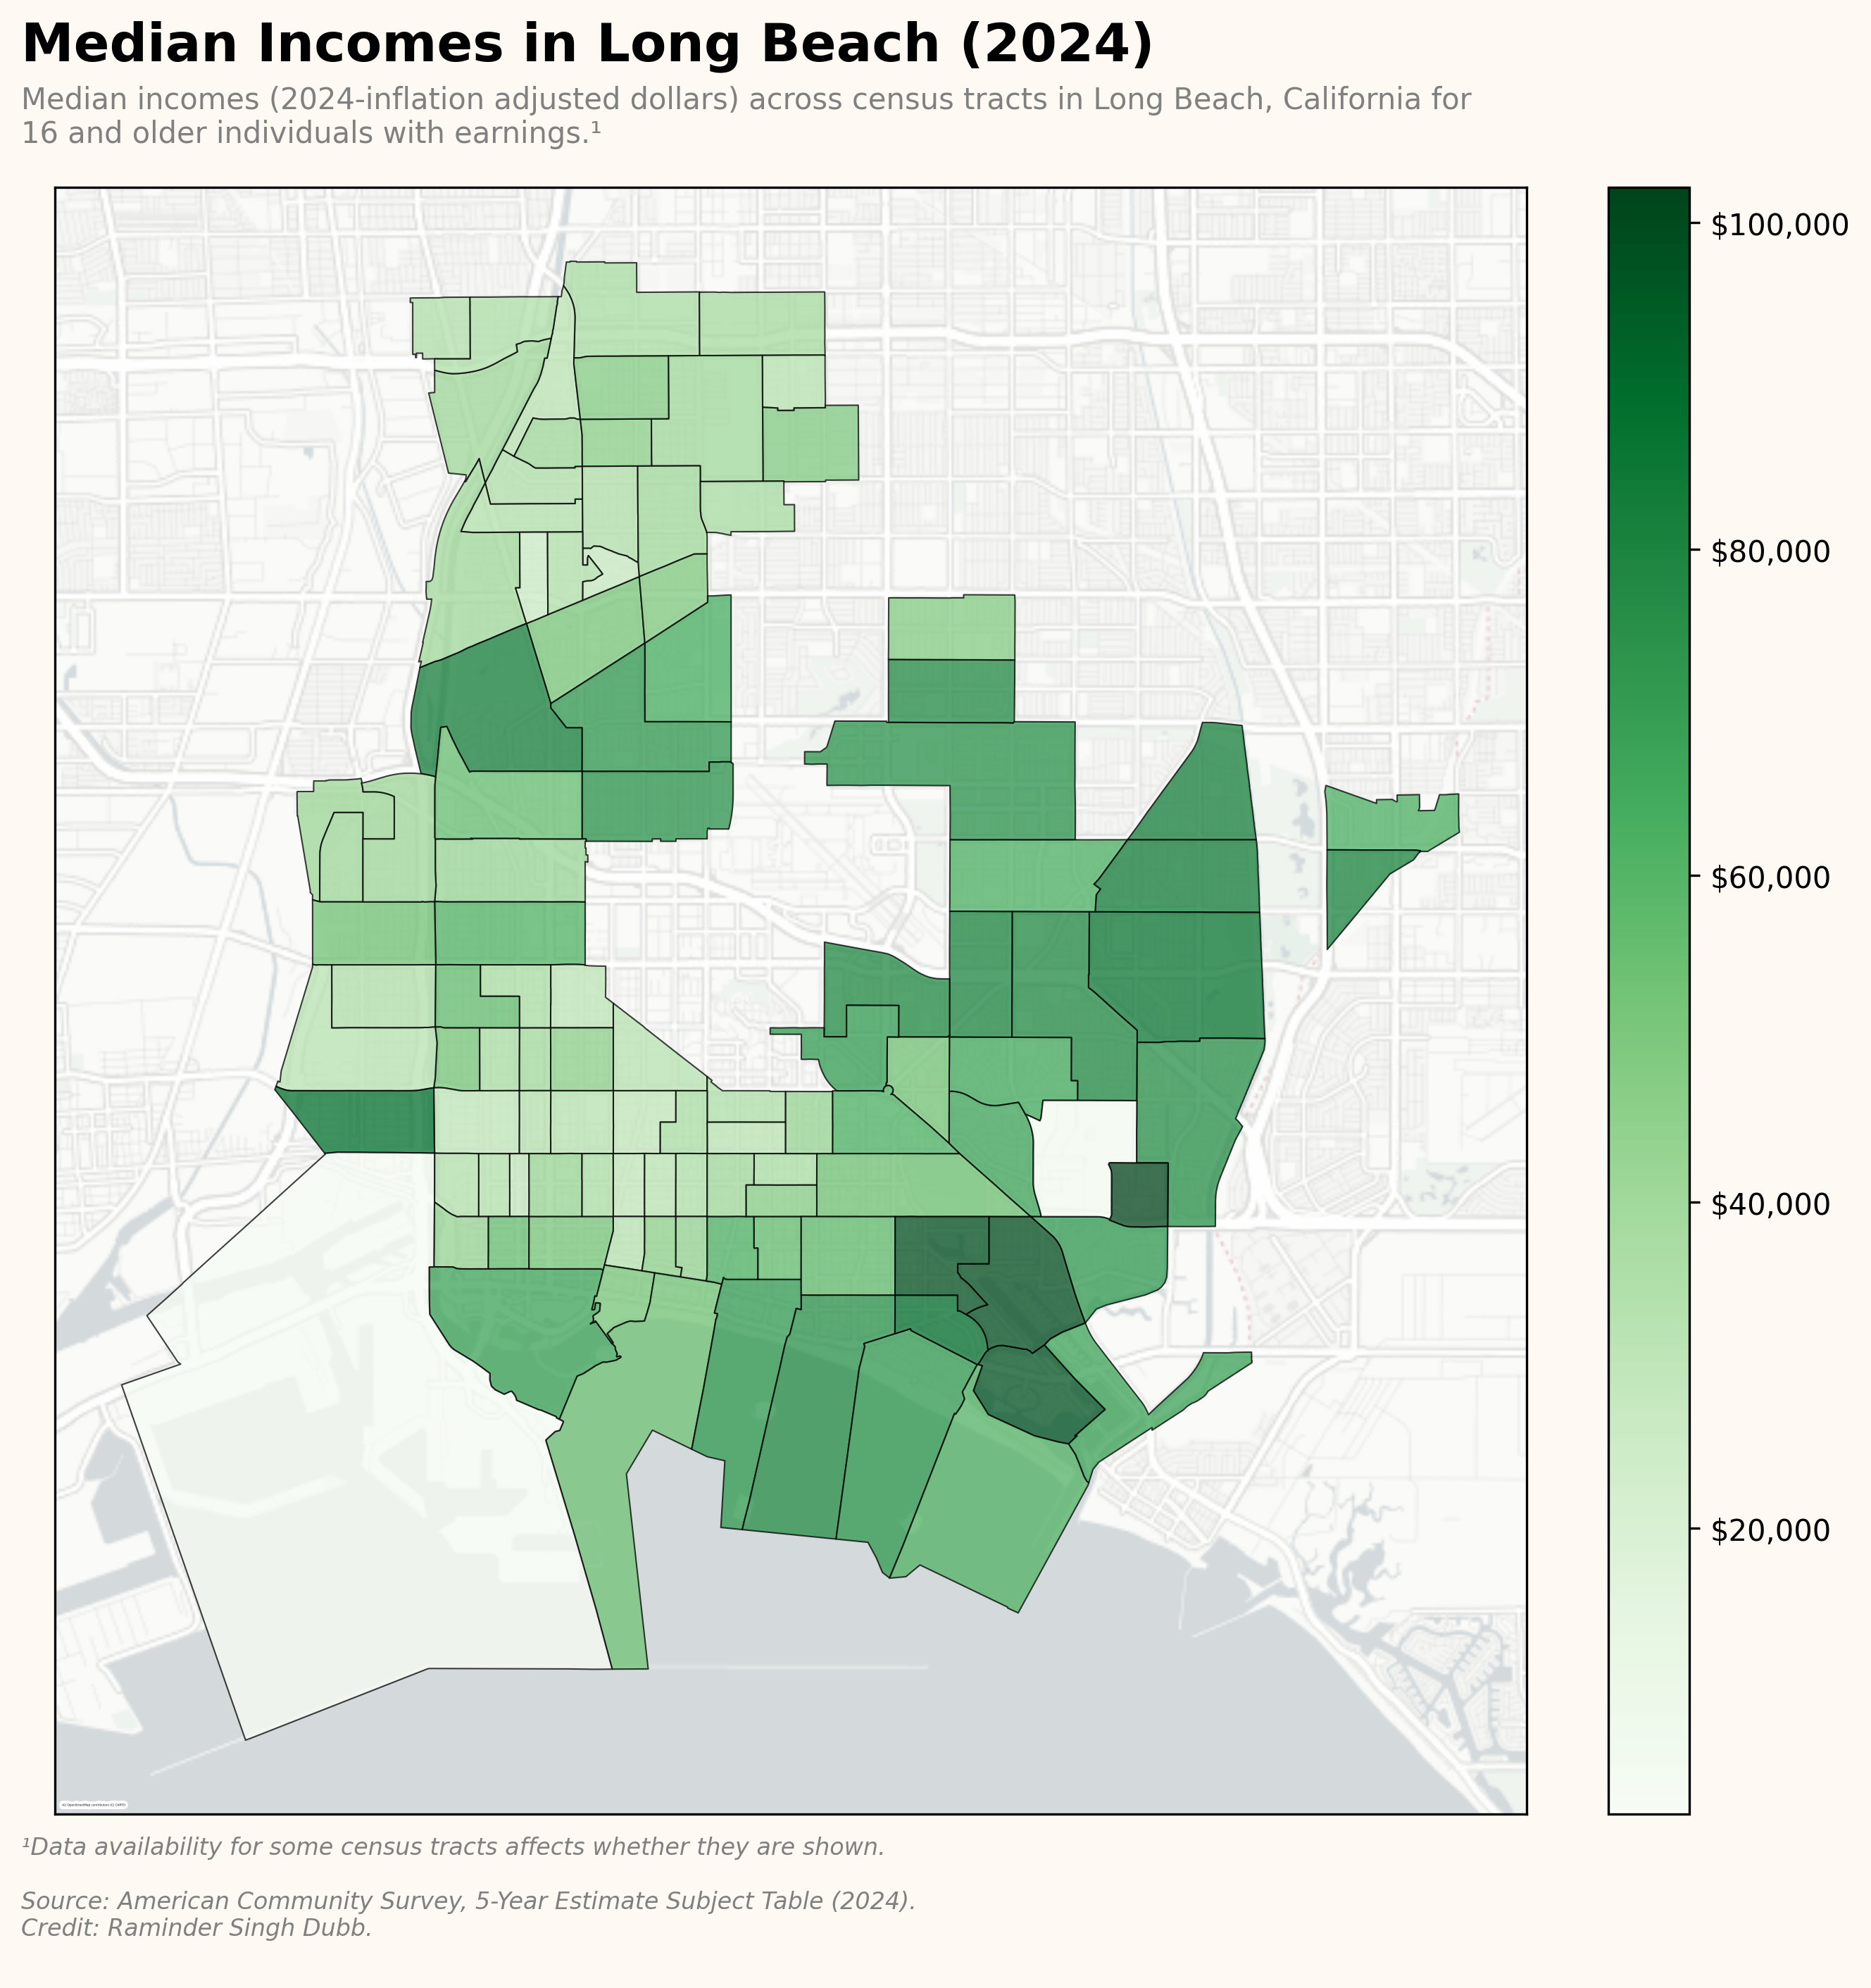

In [66]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import contextily as cx

MEDIAN_INCOME_16_AND_OLDER_EARNINGS = 'S2001_C01_002E'

fig, ax = plt.subplots(figsize = (10, 10), dpi = 300)

gdf_wm = gdf.to_crs('EPSG:3857')

gdf_wm.plot(
    ax        = ax,
    column    = MEDIAN_INCOME_16_AND_OLDER_EARNINGS,
    cmap      = 'Greens',
    edgecolor = 'black',
    linewidth = 0.5,
    alpha     = 0.75,
    zorder    = 2
)

# Adding a colorbar
norm = colors.Normalize(vmin = gdf_wm[MEDIAN_INCOME_16_AND_OLDER_EARNINGS].min(),
                        vmax = gdf_wm[MEDIAN_INCOME_16_AND_OLDER_EARNINGS].max())
mappable = plt.cm.ScalarMappable(norm = norm, cmap = 'Greens')
cbar = plt.colorbar(
    mappable,
    ax = ax,
    format = "${x:,.0f}",
    fraction = 0.05
)

# Adding a base map
cx.add_basemap(
    ax = ax,
    crs = gdf_wm.crs,
    source = cx.providers.CartoDB.PositronNoLabels,
    attribution_size = 0,
    zorder = 1
)

# Miscellaneous tweaks
ax.tick_params(
    bottom = False, top = False, left = False, right = False,
    labelbottom = False, labeltop = False, labelleft = False, labelright = False
)

fig.set_facecolor('#FEF9F3')
ax.set_facecolor('#FEF9F3')

# Title
fig.text(
    0.11, 0.94,
    "Median Incomes in Long Beach (2024)",
    fontsize = 18,
    weight = 'bold',
    color = 'black',
)

# Subtext
subtext = \
"""
Median incomes (2024-inflation adjusted dollars) across census tracts in Long Beach, California for
16 and older individuals with earnings.¹
"""
fig.text(
    0.11, 0.885,
    subtext,
    fontsize = 10,
    color = 'gray',
)

# Captions
captions = \
"""
¹Data availability for some census tracts affects whether they are shown.

Source: American Community Survey, 5-Year Estimate Subject Table (2024).
Credit: Raminder Singh Dubb.
"""
fig.text(
    0.11, 0.04,
    captions,
    fontsize = 8,
    color = 'gray',
    style = 'italic'
)

plt.show()

What we have effectively accomplished is allow tract-level geographies (the inner-layer scope), which was previously only restricted to the outer-layer scopes of either state or county, be restricted to a new outer-layer scope.